## Introduction

## Preparation

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Download dataset
# path = "mdmahfuzsumon/large-scale-financial-fraud-dataset"
path = r"C:\Users\Pablo\Documents\Data_projects\2604_predictive_model_financial_fraud\improved_fraud_dataset.csv"
df = pd.read_csv(path)

In [3]:
# Visualize dataframe information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   organization           1000000 non-null  object 
 1   transaction_id         1000000 non-null  object 
 2   user_id                1000000 non-null  object 
 3   user_account_age_days  1000000 non-null  int64  
 4   kyc_verified           1000000 non-null  int64  
 5   payment_method         1000000 non-null  object 
 6   card_type              1000000 non-null  object 
 7   transaction_amount     1000000 non-null  float64
 8   currency               1000000 non-null  object 
 9   fee_amount             1000000 non-null  float64
 10  transaction_timestamp  1000000 non-null  object 
 11  day_of_week            1000000 non-null  object 
 12  city                   1000000 non-null  object 
 13  country                1000000 non-null  object 
 14  device_type        

In [4]:
# Show dataframe shape
print(f"Loaded Dataset: {df.shape[0]} rows, {df.shape[1]} columns")

Loaded Dataset: 1000000 rows, 24 columns


In [5]:
# Show dataframe first rows
print(df.head(3))

     organization transaction_id               user_id  user_account_age_days  \
0  FinovaTech_000    TXN00000044  FinovaTech_000_U0000                   1670   
1  FinovaTech_000    TXN00000004  FinovaTech_000_U0000                   1670   
2  FinovaTech_000    TXN00000033  FinovaTech_000_U0000                   1670   

   kyc_verified payment_method card_type  transaction_amount currency  \
0             1          bkash     debit             1553.81      BDT   
1             1          bkash     debit              136.49      BDT   
2             1           card    credit             3432.40      BDT   

   fee_amount  ... device_type operating_system browser merchant_category  \
0       31.08  ...      mobile          Windows  Safari           fashion   
1        2.73  ...     desktop          Android    Edge           grocery   
2       68.65  ...      tablet              iOS  Safari       electronics   

  transaction_type otp_used is_fraud hour is_night  time_diff  
0        

In [6]:
# Show dataframe last rows
print(df.tail(3))

          organization transaction_id               user_id  \
999997  FinovaTech_199    TXN00999984  FinovaTech_199_U0099   
999998  FinovaTech_199    TXN00999998  FinovaTech_199_U0099   
999999  FinovaTech_199    TXN00999972  FinovaTech_199_U0099   

        user_account_age_days  kyc_verified payment_method card_type  \
999997                    303             0           bank     debit   
999998                    303             1           bank    credit   
999999                    303             1          bkash    credit   

        transaction_amount currency  fee_amount  ... device_type  \
999997              234.90      BDT        4.70  ...      mobile   
999998             1104.45      BDT       22.09  ...     desktop   
999999              714.08      BDT       14.28  ...      mobile   

       operating_system browser merchant_category transaction_type otp_used  \
999997              iOS  Safari           fashion         purchase        0   
999998          Windows  Ch

In [7]:
print(df)

          organization transaction_id               user_id  \
0       FinovaTech_000    TXN00000044  FinovaTech_000_U0000   
1       FinovaTech_000    TXN00000004  FinovaTech_000_U0000   
2       FinovaTech_000    TXN00000033  FinovaTech_000_U0000   
3       FinovaTech_000    TXN00000050  FinovaTech_000_U0000   
4       FinovaTech_000    TXN00000047  FinovaTech_000_U0000   
...                ...            ...                   ...   
999995  FinovaTech_199    TXN00999994  FinovaTech_199_U0099   
999996  FinovaTech_199    TXN00999962  FinovaTech_199_U0099   
999997  FinovaTech_199    TXN00999984  FinovaTech_199_U0099   
999998  FinovaTech_199    TXN00999998  FinovaTech_199_U0099   
999999  FinovaTech_199    TXN00999972  FinovaTech_199_U0099   

        user_account_age_days  kyc_verified payment_method card_type  \
0                        1670             1          bkash     debit   
1                        1670             1          bkash     debit   
2                        16

In [8]:
print(df['transaction_timestamp'].head())

0    2024-01-26 08:20:20
1    2024-02-15 06:00:28
2    2024-02-24 19:47:58
3    2024-03-07 19:30:22
4    2024-03-12 12:58:07
Name: transaction_timestamp, dtype: object


## Data cleaning

In [9]:
# ========================
# Cleaning headers
# ========================
print(df.columns)

Index(['organization', 'transaction_id', 'user_id', 'user_account_age_days',
       'kyc_verified', 'payment_method', 'card_type', 'transaction_amount',
       'currency', 'fee_amount', 'transaction_timestamp', 'day_of_week',
       'city', 'country', 'device_type', 'operating_system', 'browser',
       'merchant_category', 'transaction_type', 'otp_used', 'is_fraud', 'hour',
       'is_night', 'time_diff'],
      dtype='object')


In [10]:
# ===================================
# Cleaning numerical columns
# ===================================
numeric = df[['user_account_age_days', 'transaction_amount', 'fee_amount', 'hour', 'time_diff']]
print(numeric.head(3))

   user_account_age_days  transaction_amount  fee_amount  hour  time_diff
0                   1670             1553.81       31.08     8        0.0
1                   1670              136.49        2.73     6  1719608.0
2                   1670             3432.40       68.65    19   827250.0


- Headers and numerical columns are clean

In [11]:
# =====================================
# Cleaning categorial typos
# =====================================

categorical = df[['organization', 'transaction_id', 'user_id', 'payment_method', 'card_type', 'currency', 'day_of_week','city', 'country', 'device_type', 'operating_system', 'browser',
       'merchant_category', 'transaction_type']]
# Verify that there are no duplicates in the categorical columns
print(f"There are {categorical.duplicated().sum()} duplicates.")
print()

for col in categorical:
    print(col)
    print(categorical[col].unique())
    print()


There are 0 duplicates.

organization
['FinovaTech_000' 'FinovaTech_001' 'FinovaTech_002' 'FinovaTech_003'
 'FinovaTech_004' 'FinovaTech_005' 'FinovaTech_006' 'FinovaTech_007'
 'FinovaTech_008' 'FinovaTech_009' 'FinovaTech_010' 'FinovaTech_011'
 'FinovaTech_012' 'FinovaTech_013' 'FinovaTech_014' 'FinovaTech_015'
 'FinovaTech_016' 'FinovaTech_017' 'FinovaTech_018' 'FinovaTech_019'
 'FinovaTech_020' 'FinovaTech_021' 'FinovaTech_022' 'FinovaTech_023'
 'FinovaTech_024' 'FinovaTech_025' 'FinovaTech_026' 'FinovaTech_027'
 'FinovaTech_028' 'FinovaTech_029' 'FinovaTech_030' 'FinovaTech_031'
 'FinovaTech_032' 'FinovaTech_033' 'FinovaTech_034' 'FinovaTech_035'
 'FinovaTech_036' 'FinovaTech_037' 'FinovaTech_038' 'FinovaTech_039'
 'FinovaTech_040' 'FinovaTech_041' 'FinovaTech_042' 'FinovaTech_043'
 'FinovaTech_044' 'FinovaTech_045' 'FinovaTech_046' 'FinovaTech_047'
 'FinovaTech_048' 'FinovaTech_049' 'FinovaTech_050' 'FinovaTech_051'
 'FinovaTech_052' 'FinovaTech_053' 'FinovaTech_054' 'FinovaTech_0

In [12]:
# =====================================
# Cleaning booleans
# =====================================

# Verify that there are no mixed booleans columns
booleans = df[['kyc_verified', 'otp_used', 'is_fraud', 'is_night']]

for col in booleans:
    print(col)
    print(booleans[col].unique())
    print()

kyc_verified
[1 0]

otp_used
[1 0]

is_fraud
[0 1]

is_night
[0 1]



In [13]:
# =====================================
# Date parsing
# =====================================

# Check the type
print(df['transaction_timestamp'].dtype)

# Change of column type for date
df['transaction_timestamp'] = pd.to_datetime(df['transaction_timestamp'], yearfirst=True,errors='coerce')

print()
print("Fix applied")
print(df['transaction_timestamp'].dtype)

object

Fix applied
datetime64[ns]


## Exploratory Data Analysis

is_fraud
0    908290
1     91710
Name: is_fraud, dtype: int64



C:\Users\Pablo\AppData\Local\Temp\ipykernel_10544\566693496.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


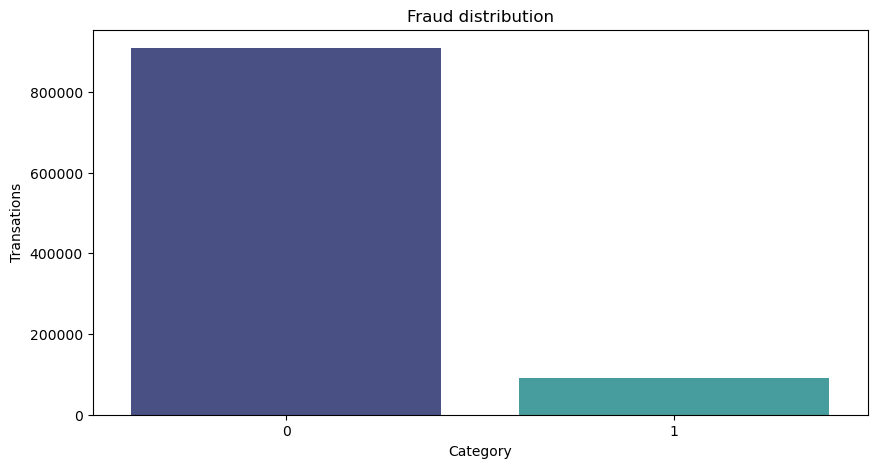

In [14]:
print(df.groupby(['is_fraud'])['is_fraud'].count())
print()
# Plot fraud distribution
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='is_fraud',
    palette="mako"
)

plt.title("Fraud distribution")
plt.xlabel("Category")
plt.ylabel("Transations")
plt.show()

### Fraud vs Numerical features

In [ ]:
fraud_vs_amount = df.groupby(['is_fraud'])['transaction_amount'].mean()

print(fraud_vs_amount)

is_fraud
0    2001.396134
1    2022.402542
Name: transaction_amount, dtype: float64



In [17]:
fraud_vs_time_diff = df.groupby(['is_fraud'])['time_diff'].mean()

print(fraud_vs_time_diff)

is_fraud
0    1.220210e+06
1    1.167106e+06
Name: time_diff, dtype: float64


In [18]:
fraud_vs_account_long = df.groupby(['is_fraud'])['user_account_age_days'].mean()

print(fraud_vs_account_long)

is_fraud
0    1004.989733
1    1006.694199
Name: user_account_age_days, dtype: float64


### Fraud vs Categorical features

In [25]:
fraud_vs_pmethod = df[df['is_fraud'] == 1].groupby(['payment_method'])['payment_method'].count().sort_values(ascending=False)

print(fraud_vs_pmethod)

payment_method
card     23057
bkash    23010
nagad    22846
bank     22797
Name: payment_method, dtype: int64


In [26]:
fraud_vs_card = df[df['is_fraud'] == 1].groupby(['card_type'])['card_type'].count().sort_values(ascending=False)

print(fraud_vs_card)

card_type
debit     46037
credit    45673
Name: card_type, dtype: int64


In [27]:
fraud_vs_device = df[df['is_fraud'] == 1].groupby(['device_type'])['device_type'].count().sort_values(ascending=False)

print(fraud_vs_device)

device_type
tablet     30615
desktop    30573
mobile     30522
Name: device_type, dtype: int64


In [28]:
fraud_vs_merchant = df[df['is_fraud'] == 1].groupby(['merchant_category'])['merchant_category'].count().sort_values(ascending=False)

print(fraud_vs_merchant)

merchant_category
fashion        23070
grocery        23064
travel         23046
electronics    22530
Name: merchant_category, dtype: int64


In [29]:
fraud_vs_transaction = df[df['is_fraud'] == 1].groupby(['transaction_type'])['transaction_type'].count().sort_values(ascending=False)

print(fraud_vs_transaction)

transaction_type
withdrawal    30596
purchase      30577
transfer      30537
Name: transaction_type, dtype: int64


In [30]:
fraud_vs_city = df[df['is_fraud'] == 1].groupby(['city'])['city'].count().sort_values(ascending=False)

print(fraud_vs_city)

city
Chittagong    23077
Rajshahi      22970
Dhaka         22895
Khulna        22768
Name: city, dtype: int64


In [31]:
fraud_vs_day = df[df['is_fraud'] == 1].groupby(['day_of_week'])['day_of_week'].count().sort_values(ascending=False)

print(fraud_vs_day)

day_of_week
Tuesday      13272
Wednesday    13229
Thursday     13217
Monday       13185
Friday       13055
Sunday       13013
Saturday     12739
Name: day_of_week, dtype: int64


In [33]:
fraud_vs_opsystem = df[df['is_fraud'] == 1].groupby(['operating_system'])['operating_system'].count().sort_values(ascending=False)

print(fraud_vs_opsystem)

operating_system
Windows    30739
iOS        30677
Android    30294
Name: operating_system, dtype: int64


In [34]:
fraud_vs_browser = df[df['is_fraud'] == 1].groupby(['browser'])['browser'].count().sort_values(ascending=False)

print(fraud_vs_browser)

browser
Chrome    30617
Edge      30570
Safari    30523
Name: browser, dtype: int64


### Fraud vs Boolean Features

In [ ]:
# Fraud vs boolean
# ['kyc_verified', 'otp_used', 'is_fraud', 'is_night']

In [38]:
fraud_kyc = df[df['is_fraud'] == 1].groupby(['kyc_verified'])['kyc_verified'].count()

print(fraud_kyc)

kyc_verified
0    18413
1    73297
Name: kyc_verified, dtype: int64


In [39]:
fraud_otp = df[df['is_fraud'] == 1].groupby(['otp_used'])['otp_used'].count()

print(fraud_otp)

otp_used
0    27645
1    64065
Name: otp_used, dtype: int64


In [40]:
fraud_vs_night = df[df['is_fraud'] == 1].groupby(['is_night'])['is_night'].count()

print(fraud_vs_night)

is_night
0     4325
1    87385
Name: is_night, dtype: int64


### Fraud vs Time

In [51]:
fraud_vs_hour = df[df['is_fraud'] == 1].groupby(['hour'])['hour'].count()

print(fraud_vs_hour)

hour
0     12543
1     12598
2     12415
3     12419
4     12382
5     12476
6       262
7       235
8       241
9       276
10      247
11      251
12      224
13      252
14      280
15      280
16      238
17      259
18      252
19      251
20      268
21      278
22      231
23    12552
Name: hour, dtype: int64


## Prepation before modeling

## Modeling

## Conclusions